#1.Data Quality Assessment

##1.1.Importing File

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1VzYlJhyImkD3JVUuNPf66ycrrugINAA3/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1VUFfDkoJP1slgm645ycA_-KIGySmx2Fd/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/138bHAL4GZNfW7Ro0smVv9IcaOBVy7dhf/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [ ]:
orderlines_cl.sample(10)

,id,id_order,product_quantity,sku,unit_price,date,is_free_item
94151,1299317,380596,2,GTE0105,999.99,2017-07-21 21:20:13,False
278472,1626073,516982,1,MMW0016,22.99,2018-02-24 23:09:31,False
145612,1404414,425319,1,PAC0702,298.58,2017-11-11 15:49:21,False
148959,1413021,428157,1,LAC0129,230.79,2017-11-18 12:31:37,False
287675,1641458,523840,1,PAC2140,2925.00,2018-03-09 14:29:05,False
130488,1377214,412101,1,GOP0096,159.99,2017-10-13 12:09:50,False
40906,1204931,335130,1,LGE0052,469.99,2017-03-14 18:51:49,False
270921,1612994,511160,1,BEL0311,19.99,2018-02-14 06:20:33,False
102948,1315285,388148,1,OWC0220-2,377.99,2017-08-10 11:46:09,False
179385,1465736,451134,1,MMW0016,22.99,2017-11-29 01:22:35,False


In [ ]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
product_qu = products_cl.copy()

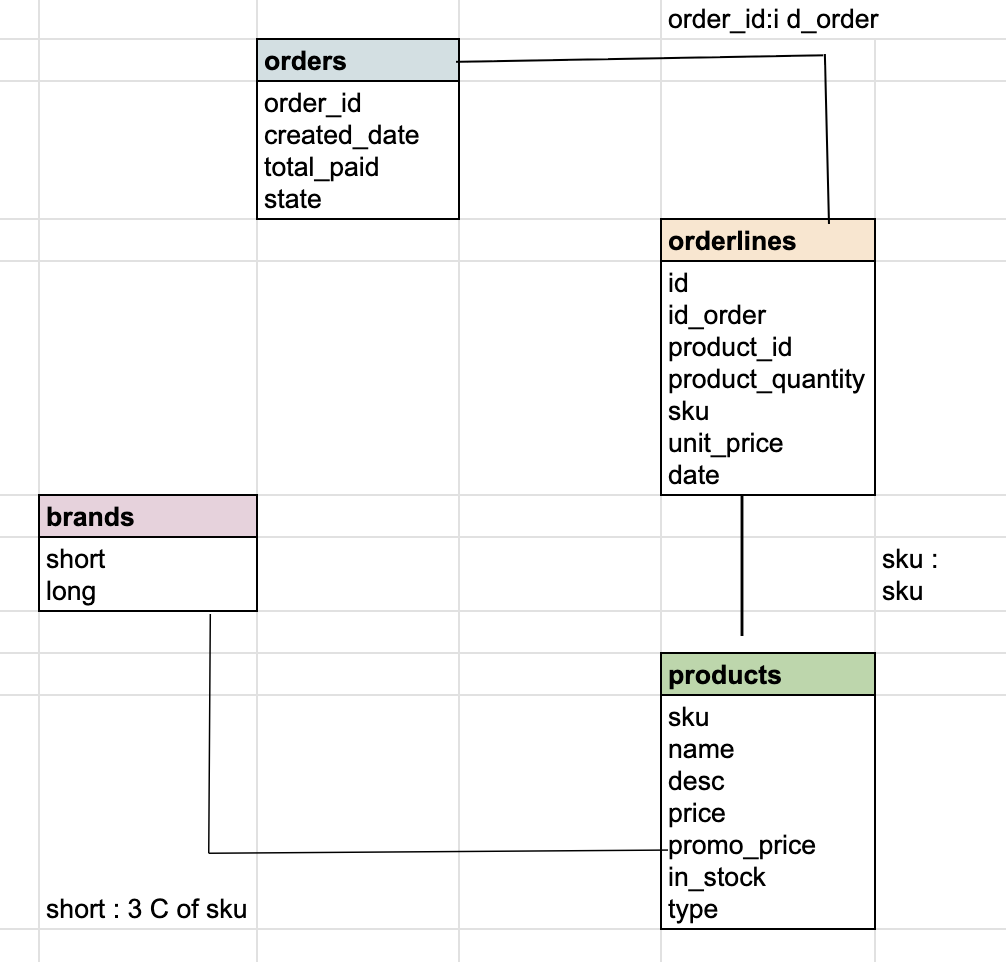

##1.2.Defining display

In [ ]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)
pd.set_option("display.max_rows", 1000)

##1.3.Quality Assessment

### 1.3.1.Time Assessment

In [ ]:
#converting created_date to date64 , date to date64
orders_qu['created_date']=pd.to_datetime(orders_qu['created_date'])
orderlines_qu['date']=pd.to_datetime(orderlines_qu['date'])

In [ ]:
#Exercise 2: Create a new column in the orderlines table with the day of the week (e.g. "Wednesday"): created_date should be changed to date64 (section 2.4.1 it has been changed)
orders_qu['Day'] = orders_qu['created_date'].dt.day_name()
orders_qu['Day'].head(10)

,Day
0,Monday
1,Monday
2,Sunday
3,Thursday
4,Friday
5,Wednesday
6,Saturday
7,Tuesday
8,Sunday
9,Monday


In [ ]:
#Exercise 3: How many orders were completed between Oct 4th 2017 and Jan 3rd 2018? (04/10/2017 and 03/01/2018)
Orders_Oct_Jan = orders_qu[orders_qu['created_date'].between('2017-10-04','2018-01-03')&(orders_qu['state']== 'Completed')]
Orders_count = len(Orders_Oct_Jan)
Orders_count

16157

In [ ]:
#Exercise 4: Are there any orders in the orderlines data frame that aren't in the orders data frame? What about orders in the orders data frame that arent in the orderlines data frame?

# Orderlines whose id_order is missing in orders_qu
missing_order_ids_in_orders = orderlines_qu.loc[
    ~orderlines_qu['id_order'].isin(orders_qu['order_id']),
    'id_order'
].nunique()

# Orders whose order_id is missing in orderlines_qu
missing_order_ids_in_orderlines = orders_qu.loc[
    ~orders_qu['order_id'].isin(orderlines_qu['id_order']),
    'order_id'
].nunique()

print(f'Orders missing in orders_qu: {missing_order_ids_in_orders}')
print(f'Orders missing in orderlines_qu: {missing_order_ids_in_orderlines}')

Orders missing in orders_qu: 164
Orders missing in orderlines_qu: 22213


In [ ]:
#Exercise 5: Create a new column in the orders data frame with the total quantity of items in each order
# 1: count the total_quantity from Orderlines_df
total_qty = (
    orderlines_qu
    .groupby('id_order')['product_quantity']
    .sum()
    .rename('total_qty')
)

# 2: merge to orders_qu
orders_qu = orders_qu.merge(
    total_qty,
    left_on='order_id',
    right_index=True,
    how='left'
)

orders_qu.head(10)

,order_id,created_date,total_paid,state,Day,total_qty
0,241319,2017-01-02 13:35:40,44.99,Cancelled,Monday,1.00
1,241423,2017-11-06 13:10:02,136.15,Completed,Monday,1.00
2,242832,2017-12-31 17:40:03,15.76,Completed,Sunday,1.00
3,243330,2017-02-16 10:59:38,84.98,Completed,Thursday,1.00
4,243784,2017-11-24 13:35:19,157.86,Cancelled,Friday,3.00
5,245275,2017-06-28 11:35:37,149.00,Completed,Wednesday,1.00
6,245595,2017-01-21 12:52:47,112.97,Completed,Saturday,2.00
7,245851,2017-04-04 20:58:21,79.99,Pending,Tuesday,1.00
8,245941,2017-01-01 10:32:23,183.52,Completed,Sunday,NaN
9,246018,2017-02-13 23:02:57,211.95,Completed,Monday,4.00


<Axes: xlabel='created_date'>

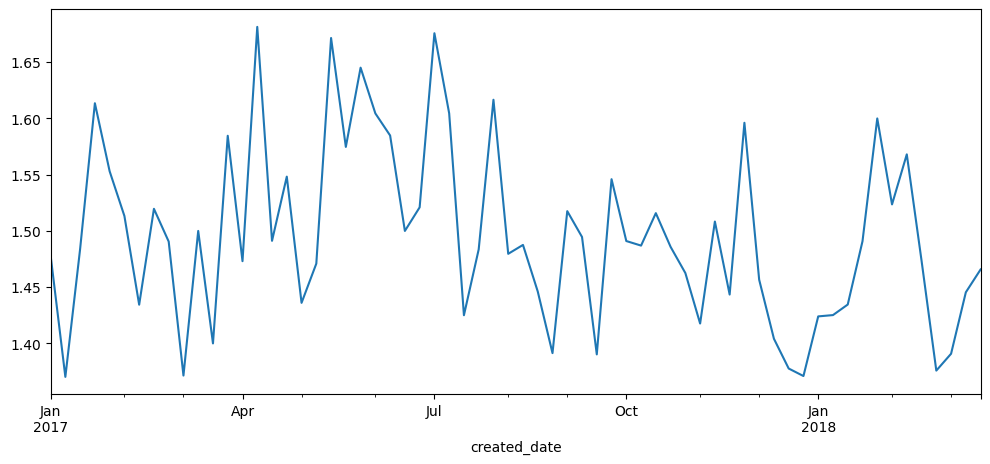

In [ ]:
#Bonus: Plot how the average quantity per order evolved weekly over the snapshot in the orders data frame. (Bonus: include only completed orders)
#1:finding completed orders in orders_qu
completed_orders = orders_qu[orders_qu['state']=='Completed'].copy()
#print(f'completed_ordes:{completed_orders}')
#2:then sorting created_date
completed_orders_sorted = completed_orders.sort_values('created_date').copy()
#3:indexing created_date then using in resample()
completed_orders = completed_orders.set_index('created_date')
weekly_avg= completed_orders.resample('W-MON')['total_qty'].mean()
#4:plotting
weekly_avg.plot(figsize=(12,5))

### 1.3.2.Orders Assessment

In [ ]:
#What's the latest order?
latest_order = orders_qu['created_date'].max()
print(f'latest order is : {latest_order}')

latest order is : 2018-03-14 13:58:36


In [ ]:
#Use .strftime() to print out the latest order as "Wed, 14/03/2018".
str_format = latest_order.strftime('%a, %d/%m/%Y')
print(f'latest order is (strftime): {str_format}')

latest order is (strftime): Wed, 14/03/2018


In [ ]:
#What's the order number of the first order sold in June 2017?
june_2017 = orders_qu[orders_qu['created_date'].between('2017-06-01','2017-06-30 23:59:59')&(orders_qu['state']== 'Completed')]
first_order_june_2017 = june_2017.sort_values('created_date').iloc[0]
print(f'first order sold in june 2017 : {first_order_june_2017["order_id"]}')

first order sold in june 2017 : 360369


In [ ]:
#How many orders, regardless of state, were processed between 15th April 2017 and 6th May 2017?
#time Filtering
orders_period = orders_qu[orders_qu['created_date'].between('2017-04-15', '2017-05-06 23:59:59')]
#orders count
count = len(orders_period)
print(f'orders count : {count}')

orders count : 1600


<Axes: title={'center': 'Orders Daily'}, xlabel='Month', ylabel='numbers of orders'>

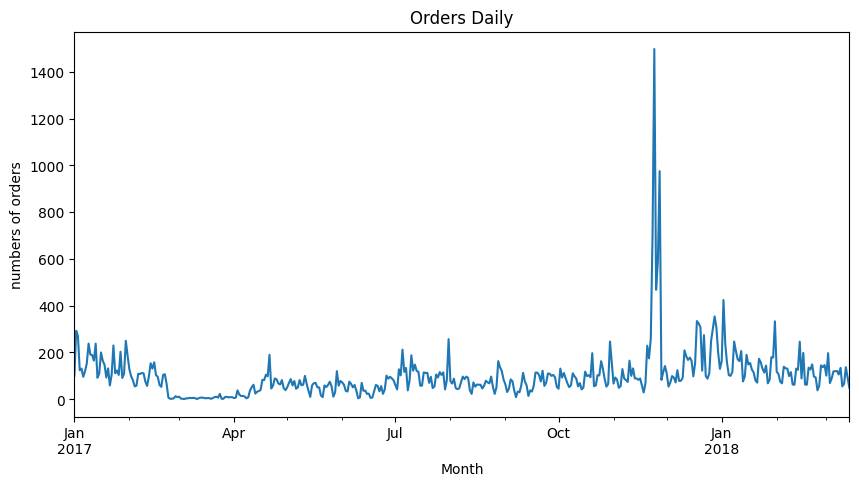

In [ ]:
#Often as not, you may wish not only to read grouped information, but plot it.
#Use pandas `.plot()` to create a daily graph for the number of orders placed.
orders_daily = (orders_qu.resample('D', on='created_date')['order_id'])
orders_daily.count().plot(title='Orders Daily',xlabel='Month',ylabel='numbers of orders',figsize=(10,5))

<Axes: title={'center': 'Orders Daily'}, xlabel='Month', ylabel='numbers of orders'>

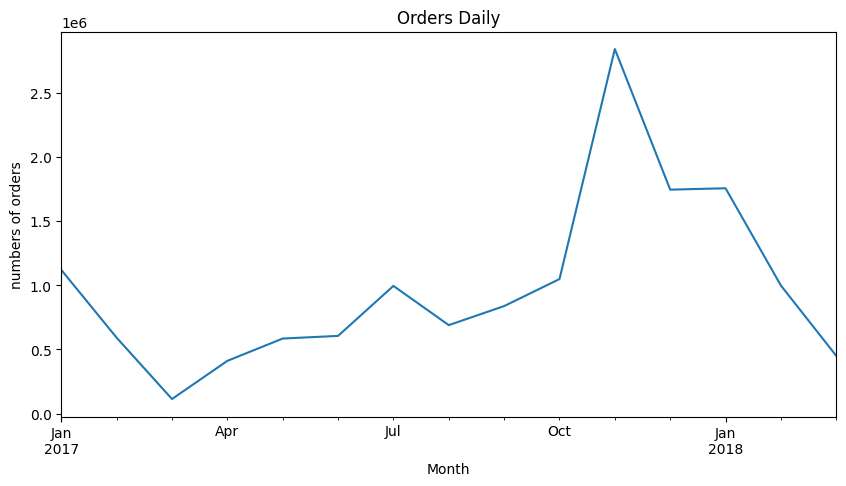

In [ ]:
orders_daily = (orders_qu.resample('ME', on='created_date')['total_paid'])
orders_daily.sum().plot(title='Orders Daily',xlabel='Month',ylabel='numbers of orders',figsize=(10,5))

###1.3.3 Price assessment

What is the average difference between total_paid and unit_price_total?
What is the distribution of these differences?
Can all the differences be explained by shipping costs? If not, what are other plausible explanations?
If there are differences that you can’t explain: what should you do with these orders?

What is the average difference between total_paid and unit_price_total?

In [ ]:
#orders:total_paid,order_id , odersline:unit_price, product_quantity,id_order
#1:calculate unit_price*product_quatity in new column
orderlines_qu['unit_price_quantity'] =orderlines_qu['unit_price'] * orderlines_qu['product_quantity']
#2:
order_total = orderlines_qu.groupby('id_order').agg(
    unit_price_total=('unit_price_quantity', 'sum'),
    orderline_count=('id_order', 'count')
)
#3:
Order_merge_total = orders_qu.merge(order_total,left_on='order_id',right_on='id_order',how='inner')
#4:calculate Diff
Order_merge_total['Diff'] = Order_merge_total['total_paid']- Order_merge_total['unit_price_total']
avg_diff = Order_merge_total['Diff'].mean()
avg_diff

np.float64(3.1019627145306825)

In [ ]:
print(Order_merge_total[['order_id', 'total_paid', 'unit_price_total', 'Diff']].head(20))

    order_id  total_paid  unit_price_total  Diff
0     241423      136.15            129.16  6.99
1     242832       15.76             10.77  4.99
2     243330       84.98             77.99  6.99
3     245275      149.00            149.00  0.00
4     245595      112.97            105.98  6.99
5     247524      167.98            162.99  4.99
6     247643      153.54            153.54  0.00
7     250275       54.99             51.00  3.99
8     251302      140.99            140.99  0.00
9     253220     1610.00           1609.99  0.01
10    253307      292.04            285.05  6.99
11    254301       35.91             28.92  6.99
12    254341       34.98             34.98  0.00
13    254441       56.98             49.99  6.99
14    254816      283.83            276.84  6.99
15    256158      386.18            386.18  0.00
16    256679       20.58             13.59  6.99
17    256799       20.97              7.98 12.99
18    257280      260.00            260.00  0.00
19    257847     136

<Axes: >

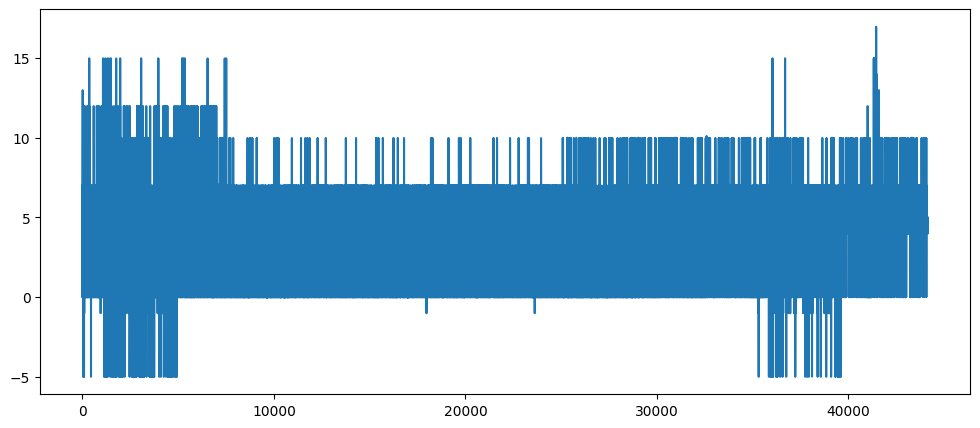

In [ ]:
Order_merge_total['Diff'].plot(figsize=(12,5))

In [ ]:
Order_merge_total

,order_id,created_date,total_paid,state,Day,total_qty,unit_price_total,orderlines_qu,Diff
0,241423,2017-11-06 13:10:02,136.15,Completed,Monday,1.00,129.16,1,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,Sunday,1.00,10.77,1,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,Thursday,1.00,77.99,1,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,Wednesday,1.00,149.00,1,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,Saturday,2.00,105.98,1,6.99
...,...,...,...,...,...,...,...,...,...
44140,527042,2018-03-14 11:47:50,18.98,Completed,Wednesday,1.00,13.99,1,4.99
44141,527070,2018-03-14 11:50:48,24.97,Completed,Wednesday,2.00,19.98,1,4.99
44142,527074,2018-03-14 11:51:42,24.97,Completed,Wednesday,2.00,19.98,1,4.99
44143,527096,2018-03-14 11:58:40,34.96,Completed,Wednesday,3.00,29.97,1,4.99


What is the distribution of these differences?

The differences are highly concentrated around zero. The median difference is 0, and 75% of the observations have a difference of 0.01 or less. However, the distribution contains extreme positive and negative outliers, ranging from -36,159.90 to 149,989.83. These extreme values substantially increase the standard deviation (456.54) and influence the mean difference (3.78). Therefore, the distribution is highly skewed and not normally distributed.

In [ ]:
Order_merge_total['Diff'].describe()

,Diff
count,44145.00
mean,3.77
std,2.91
min,-5.00
25%,0.00
50%,4.99
75%,6.99
max,16.97


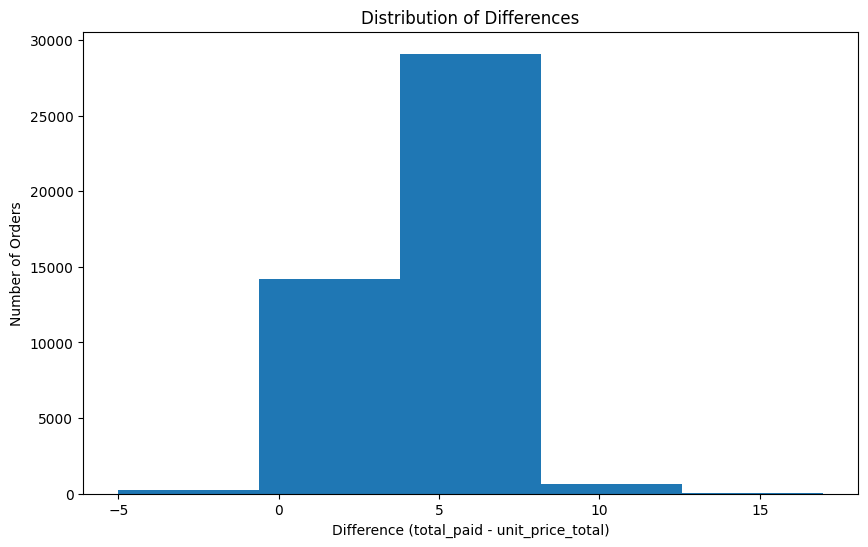

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(Order_merge_total['Diff'], bins=5)

plt.xlabel('Difference (total_paid - unit_price_total)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Differences')

plt.show()

In [ ]:
#checking negative
Order_merge_total[
    ['order_id', 'total_paid', 'unit_price_total', 'Diff']
].sort_values('Diff').head(20)

,order_id,total_paid,unit_price_total,Diff
4554,317177,694.15,699.15,-5.00
4099,315363,433.95,438.95,-5.00
1720,306436,156.20,161.20,-5.00
4688,317637,219.22,224.22,-5.00
2695,310232,213.98,218.98,-5.00
39546,503174,48.98,53.98,-5.00
1145,303978,50.98,55.98,-5.00
39574,503261,49.00,54.00,-5.00
451,300950,777.99,782.99,-5.00
1455,305474,687.99,692.99,-5.00


In [ ]:
Order_with_products = Order_merge_total.merge(
    orderlines_qu[['id_order', 'sku', 'unit_price', 'product_quantity']],
    left_on='order_id',
    right_on='id_order',
    how='left'
).merge(
    product_qu[['sku', 'name', 'price']],
    on='sku',
    how='left'
)

In [ ]:
Order_with_products[
    ['order_id', 'total_paid', 'unit_price_total', 'Diff',
     'sku', 'name', 'unit_price', 'product_quantity',
     'price', ]
].sort_values('Diff', ascending=False).head(20)

,order_id,total_paid,unit_price_total,Diff,sku,name,unit_price,product_quantity,price
54612,512862,20.97,4.00,16.97,MOP0109,Mophie Powerstation Mini Universal 4000mAh Bat...,2.00,2,69.95
5169,314887,857.14,842.15,14.99,APP1630,Apple iPhone 7 Plus 128GB Black,842.15,1,889.00
2504,307433,454.38,439.39,14.99,LGE0038-A,"Open - LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 ...",439.39,1,599.00
3970,311533,857.14,842.15,14.99,APP1633,Apple iPhone 7 Plus 128GB Rose Gold,842.15,1,889.00
47480,484544,229.86,214.87,14.99,BEA0080,Solo3 Beats Headphones Wireless On-Ear Gold Mate,214.87,1,299.95
9832,345441,675.32,660.33,14.99,APP2056,Open - Apple iPhone 7256 GB Black - Like New,660.33,1,989.00
1356,303595,427.39,412.40,14.99,PAR0071,Parrot Bebop 2 White + Command FLYPAD and FPV ...,412.40,1,699.00
498,300665,741.44,726.45,14.99,APP1652,Apple iPhone 7 128GB Black Bright,726.45,1,749.00
6897,319890,514.96,499.97,14.99,WDT0320,"Blue Hard Drive 4TB WD 35 ""Mac and PC",111.56,1,130.00
6816,319590,403.41,388.42,14.99,OWC0183,SSD expansion kit OWC Aura Pro 6G 480GB Retina...,388.42,1,568.99


###1.3.4. Rabbat Assessment (Georgij)

Schritt1:Setup
Schritt2: Unerwünschte Bestellungen filtern (Venn-Diagramm Logik)

In [ ]:
orders_qu = orders_qu.loc[orders_qu.state == "Completed", :]

In [ ]:
valid_ids = set(orders_qu['order_id']).intersection(set(orderlines_qu['id_order']))
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(valid_ids)]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(valid_ids)]

Schritt 3: Bestellungen mit unbekannten Produkten ausschließen

In [ ]:
product_qu['sku'] = product_qu['sku'].astype(str).str.strip().str.upper()
orderlines_qu['sku'] = orderlines_qu['sku'].astype(str).str.strip().str.upper()
product_qu = product_qu.drop_duplicates(subset=['sku'])

orderlines_products = orderlines_qu.merge(product_qu, how="left", on="sku")[["id_order","sku","name"]]


orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()


orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete),:]
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete),:]

Schritt 4: Einnahmen erforschen (Warenwert vs. Gezahlt)

In [ ]:
orderlines_qu["unit_price_total"] = orderlines_qu["product_quantity"] * orderlines_qu["unit_price"]

orderlines_order_ids = orderlines_qu.groupby("id_order", as_index=False)["unit_price_total"].sum()

diff_df = orders_qu.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]

print(diff_df.difference.mean().round(2))

3.77


Schritt 5: Unerklärbare Ausreißer entfernen (IQR-Methode)

In [ ]:
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)
IQR = Q3 - Q1

lower_boundary = Q1 - 1.5 * IQR
upper_boundary = Q3 + 1.5 * IQR

diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= lower_boundary) &
    (diff_df["difference"] <= upper_boundary), :]

normal_diff_list = diff_no_outliers_df["order_id"]
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]


Schritt 6: Hauptziel – Rabatte analysieren

In [ ]:
orderlines_products = orderlines_qu.merge(product_qu[['sku', 'price']], on='sku', how='inner')

orderlines_products['discount_euro_per_unit'] = (orderlines_products['price'] - orderlines_products['unit_price']).round(2)
orderlines_products['discount_total'] = orderlines_products['discount_euro_per_unit'] * orderlines_products['product_quantity']

orderlines_products['discount_percent'] = np.where(
    orderlines_products['price'] > 0,
    ((orderlines_products['discount_euro_per_unit'] / orderlines_products['price']) * 100).round(2),
    0.0
)

In [ ]:
orderlines_products.head(10)

,id,id_order,product_quantity,sku,unit_price,date,is_free_item,unit_price_quantity,unit_price_total,quarter,year,period_quarter,revenue,month,price,discount_euro_per_unit,discount_total,discount_percent
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,False,47.49,47.49,1,2017,2017Q1,47.49,2017-01,60.99,13.50,13.50,22.13
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,False,18.99,18.99,1,2017,2017Q1,18.99,2017-01,22.95,3.96,3.96,17.25
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,False,72.19,72.19,1,2017,2017Q1,72.19,2017-01,89.00,16.81,16.81,18.89
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,False,2565.99,2565.99,1,2017,2017Q1,2565.99,2017-01,3209.00,643.01,643.01,20.04
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,False,60.90,60.90,1,2017,2017Q1,60.90,2017-01,76.99,16.09,16.09,20.90
5,1119145,299561,1,PEB0015,142.49,2017-01-01 02:38:50,False,142.49,142.49,1,2017,2017Q1,142.49,2017-01,299.99,157.50,157.50,52.50
6,1119154,299563,1,BEA0065,256.49,2017-01-01 02:42:05,False,256.49,256.49,1,2017,2017Q1,256.49,2017-01,299.95,43.46,43.46,14.49
7,1119155,299564,1,SAT0010,18.99,2017-01-01 02:43:37,False,18.99,18.99,1,2017,2017Q1,18.99,2017-01,29.99,11.00,11.00,36.68
8,1119181,299571,1,SYN0139,166.24,2017-01-01 04:00:44,False,166.24,166.24,1,2017,2017Q1,166.24,2017-01,175.99,9.75,9.75,5.54
9,1119188,299578,1,LOG0191,142.49,2017-01-01 08:21:26,False,142.49,142.49,1,2017,2017Q1,142.49,2017-01,209.00,66.51,66.51,31.82


In [ ]:
orderlines_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57974 entries, 0 to 57973
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      57974 non-null  int64         
 1   id_order                57974 non-null  int64         
 2   product_quantity        57974 non-null  int64         
 3   sku                     57974 non-null  object        
 4   unit_price              57974 non-null  float64       
 5   date                    57974 non-null  datetime64[ns]
 6   is_free_item            57974 non-null  bool          
 7   unit_price_quantity     57974 non-null  float64       
 8   unit_price_total        57974 non-null  float64       
 9   quarter                 57974 non-null  int32         
 10  year                    57974 non-null  int32         
 11  period_quarter          57974 non-null  period[Q-DEC] 
 12  revenue                 57974 non-null  float6

###1.3.4 Discount Assessment

In [ ]:
#Completed orders
orders_qu = orders_qu.loc[orders_qu["state"] == "Completed"]

In [ ]:
#merged order und orderlines to find common orders
merged_o_ol = orders_qu.merge(orderlines_qu, left_on="order_id", right_on="id_order", how="inner")
#find complteted orders in merged
completed_orders = merged_o_ol.loc[merged_o_ol["state"] == "Completed", "order_id"]
#make oderlines_completed
orderlines_completetd = orderlines_qu.loc[orderlines_qu["id_order"].isin(completed_orders)]

Exercise 1: How many different orders are in the orderlines data frame?

In [ ]:
#finding unique orders in order_qu
orders_unique = orderlines_qu['id_order'].nunique()
print(f'orders unique in order_qu: {orders_unique}')
#finding unique orders in order_qu
orders_numbers= orderlines_qu['id_order'].count()
print(f'total orders in orderlines_qu: {orders_numbers}')

orders unique in order_qu: 204855
total orders in orderlines_qu: 293983


In [ ]:
#finding unique completed orders
print(
    f"completed orders in orderline: "
    f"{orderlines_completetd['id_order'].nunique()}"
)

completed orders in orderline: 46560


Exercise 2: How many orders are in *both* the orderlines and orders data frames

In [ ]:
#finding id_order that are completed(sold product)
orderlines_qu.loc[
    orderlines_qu["id_order"].isin(completed_orders), "id_order"
].nunique()

44145

In [ ]:
#other solution to find sold product
gemeinsame_order_ids = set( orders_qu['order_id']) & set( orderlines_qu["id_order"] )
orders_qu.loc[orders_qu["order_id"].isin(gemeinsame_order_ids)]

,order_id,created_date,total_paid,state,Day,total_qty
1,241423,2017-11-06 13:10:02,136.15,Completed,Monday,1.00
2,242832,2017-12-31 17:40:03,15.76,Completed,Sunday,1.00
3,243330,2017-02-16 10:59:38,84.98,Completed,Thursday,1.00
5,245275,2017-06-28 11:35:37,149.00,Completed,Wednesday,1.00
6,245595,2017-01-21 12:52:47,112.97,Completed,Saturday,2.00
...,...,...,...,...,...,...
226544,527042,2018-03-14 11:47:50,18.98,Completed,Wednesday,1.00
226572,527070,2018-03-14 11:50:48,24.97,Completed,Wednesday,2.00
226576,527074,2018-03-14 11:51:42,24.97,Completed,Wednesday,2.00
226598,527096,2018-03-14 11:58:40,34.96,Completed,Wednesday,3.00


Exercise 3: How many orders have more than 3 different products in them?

In [ ]:
#grouping id_order in orderlines to count sku for every id_order(finding orders have more than one product)
#orderlines_qu.groupby('id_order')['sku'].count().sort_values(ascending=False)
products_per_order = (
    orderlines_qu
    .groupby('id_order')['sku']
    .nunique()
)

print(
    'Orders with more than 3 different products (all orders):',
    (products_per_order > 3).sum()
)

products_per_order_completed = (
    orderlines_completetd
    .groupby('id_order')['sku']
    .nunique()
)

print(
    'Orders with more than 3 different products (completed orders):',
    (products_per_order_completed > 3).sum()
)

Orders with more than 3 different products (all orders): 13782
Orders with more than 3 different products (completed orders): 1117


Exercise 4: In which quarter do we usually see the most items "sold"?<br>
(Bonus: only include completed orders)

In [ ]:
#using dt.quarter to find quarter
orderlines_qu["quarter"] = orderlines_qu["date"].dt.quarter
orderlines_qu.groupby("quarter").agg({"product_quantity": "sum"})

,product_quantity
quarter,
1,24264
2,7340
3,11243
4,22138


In [ ]:
#we need every quarter for every year.the last result shows all year
orderlines_qu['date'].dt.to_period('Q').value_counts()

,count
date,
2017Q4,19880
2018Q1,12344
2017Q3,10096
2017Q1,9328
2017Q2,6326


In [ ]:
#quarter doesnot mean every 3 month of season ...that can be different...so with following code we could calculate 3 month of every season
orderlines_qu["year"] = orderlines_qu["date"].dt.year
orderlines_qu.groupby(["year","quarter"]).agg({"product_quantity": "sum"})

product_quantity
year quarter                  
2017 1                   10556
     2                    7340
     3                   11243
     4                   22138
2018 1                   13708

In [ ]:
#alternative solution
orderlines_qu["period_quarter"] = orderlines_qu['date'].dt.to_period('Q')
orderlines_qu.groupby("period_quarter").agg({"product_quantity": "sum"})

,product_quantity
period_quarter,
2017Q1,10556
2017Q2,7340
2017Q3,11243
2017Q4,22138
2018Q1,13708


In [ ]:
#good practise
(orderlines_qu.groupby(['quarter','year']).agg({'product_quantity':'sum'}).groupby('quarter').agg({'product_quantity':'mean'}))

,product_quantity
quarter,
1,12132.00
2,7340.00
3,11243.00
4,22138.00


Exercise 5: Create a line plot visualizing the evolution of the total quantity of products being "sold" daily<br>
(Bonus: only plot completed orders)

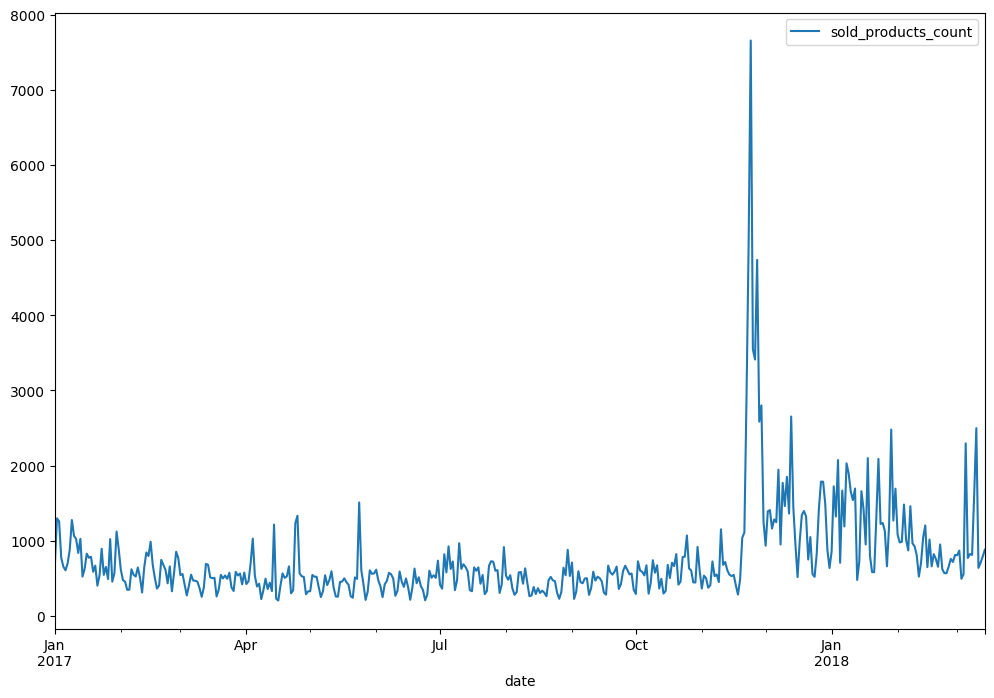

In [ ]:
(orderlines_qu
        .resample('D',on='date')
        .agg(sold_products_count=('product_quantity','sum'))
        .plot(figsize=(12,8))
);


<Axes: xlabel='date'>

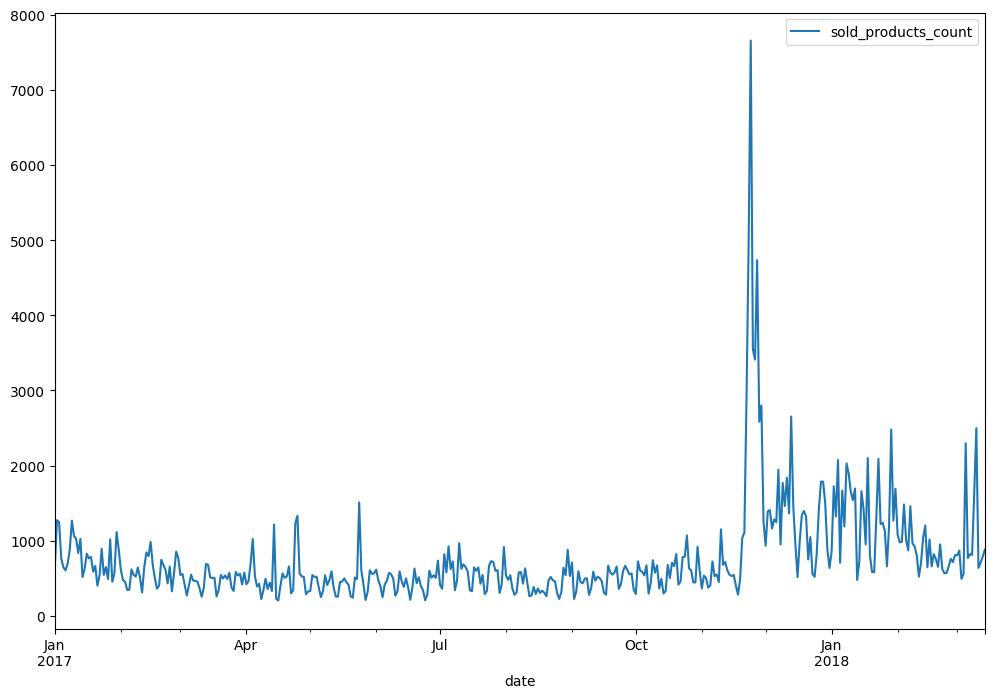

In [ ]:
(
    merged_o_ol
    .resample('D', on='date')
    .agg(sold_products_count=('product_quantity', 'sum'))
    .plot(figsize=(12, 8))
)

Create a new column called 'revenue' in the orderlines data frame by multiplying the unit price by the quantity. Create another line plot visualizing the evolution of revenue over time<br>
(Bonus: only plot completed orders)

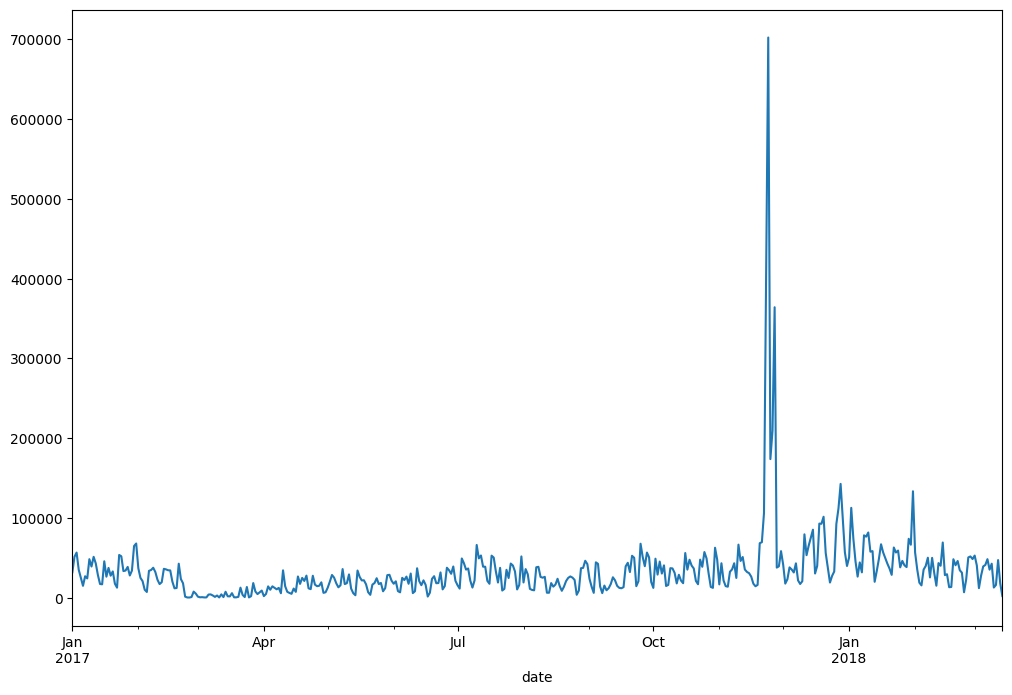

In [ ]:
orderlines_qu.loc[:,"revenue"] = orderlines_qu["unit_price"] * orderlines_qu["product_quantity"]

(
orderlines_qu
    .resample("D", on="date")
    ["revenue"].sum()
    .plot(figsize=(12,8))
);

<Axes: xlabel='date'>

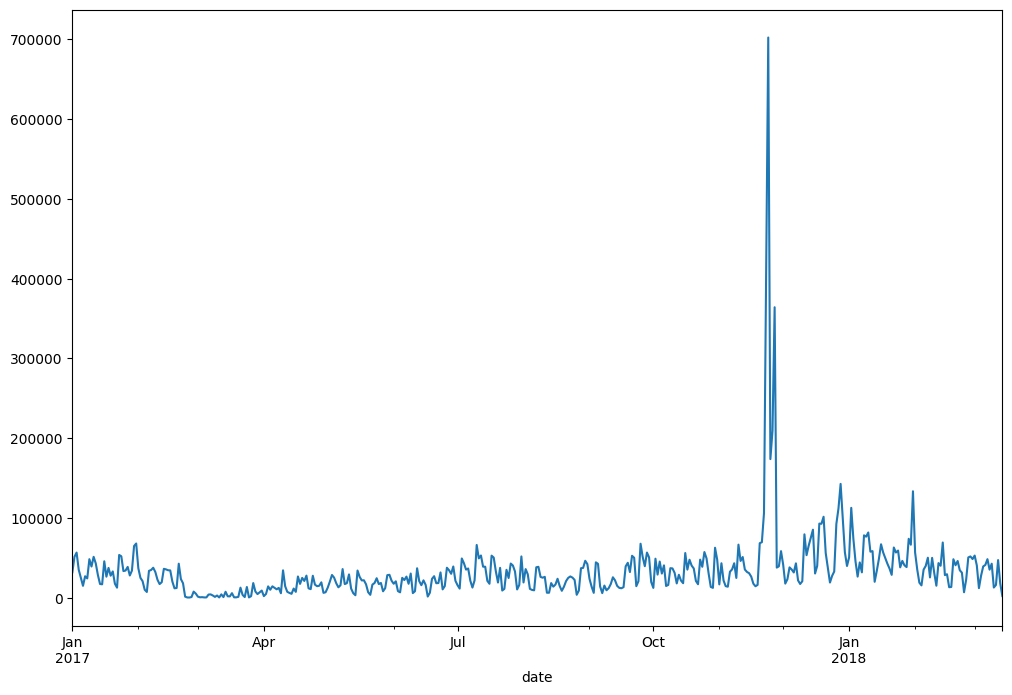

In [ ]:
merged_o_ol.loc[:,"revenue"] = merged_o_ol["unit_price"] * merged_o_ol["product_quantity"]

(
merged_o_ol
    .resample("D", on="date")
    ["revenue"].sum()
    .plot(figsize=(12,8))
)

Discount Ratio:

In [ ]:
discounted_items = orderlines_products[orderlines_products['discount_euro_per_unit'] > 0]

total_items = len(orderlines_products)
discounted_count = len(discounted_items)
percent_discounted = (discounted_count / total_items) * 100

print(f"{discounted_count} von {total_items} Produkten sind rabattiert ({percent_discounted:.2f}%).")

53900 von 57974 Produkten sind rabattiert (92.97%).


Discount Distribution:

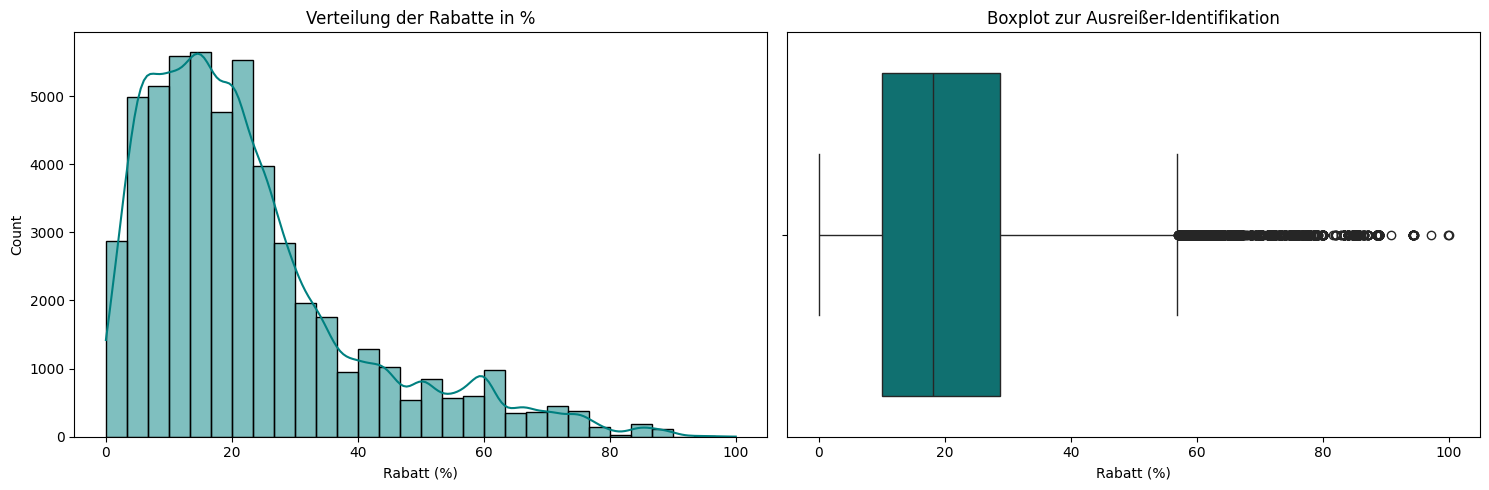

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(discounted_items['discount_percent'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Verteilung der Rabatte in %')
axes[0].set_xlabel('Rabatt (%)')

sns.boxplot(x=discounted_items['discount_percent'], ax=axes[1], color='teal')
axes[1].set_title('Boxplot zur Ausreißer-Identifikation')
axes[1].set_xlabel('Rabatt (%)')

plt.tight_layout()
plt.show()

Top Products Discount Profile:

In [ ]:
top_revenue_overall = orderlines_products.groupby('sku').agg(
    total_revenue=('unit_price_total', 'sum'),
    total_quantity=('product_quantity', 'sum'),
    avg_discount_percent=('discount_percent', 'mean')
).sort_values('total_revenue', ascending=False).head(10)

print("Die Top 10 umsatzstärksten Produkte insgesamt:")
display(top_revenue_overall)

Die Top 10 umsatzstärksten Produkte insgesamt:


,total_revenue,total_quantity,avg_discount_percent
sku,,,
APP2075,212411.11,70,8.19
APP2074,153884.97,60,8.58
LGE0044,138237.79,244,5.30
APP2489,130131.00,114,1.51
APP2072,129397.08,131,10.65
PAC2136,126672.95,60,9.76
APP2073,121385.77,99,9.52
APP2089,113149.65,58,7.42
APP1956,105459.33,57,33.25


Revenue vs. Discount over Time:

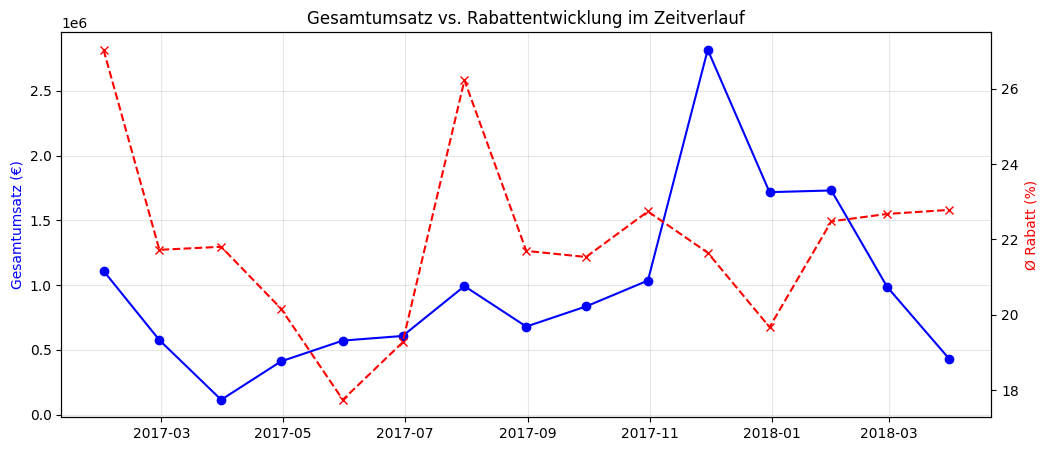

In [ ]:
monthly_revenue_all = orderlines_products.set_index('date').resample('ME').agg(
    total_monthly_revenue=('unit_price_total', 'sum')
)

monthly_discount_trend = discounted_items.set_index('date').resample('ME').agg(
    avg_monthly_discount=('discount_percent', 'mean')
)

monthly_trend = monthly_revenue_all.merge(monthly_discount_trend, left_index=True, right_index=True)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(monthly_trend.index, monthly_trend['total_monthly_revenue'], color='blue', marker='o', label='Gesamtumsatz (€)')
ax2.plot(monthly_trend.index, monthly_trend['avg_monthly_discount'], color='red', linestyle='--', marker='x', label='Ø Rabatt %')

ax1.set_ylabel('Gesamtumsatz (€)', color='blue')
ax2.set_ylabel('Ø Rabatt (%)', color='red')
plt.title('Gesamtumsatz vs. Rabattentwicklung im Zeitverlauf')
ax1.grid(True, alpha=0.3)
plt.show()

Konzentration: Die überwiegende Mehrheit der gewährten Rabatte bewegt sich in einem moderaten Rahmen (z. B. 5 % - 20 %). Dies spricht für reguläre, geplante Promo-Aktionen.

Ausreißer: Der Boxplot zeigt deutliche Ausreißer mit extrem hohen Preisnachlässen (teilweise über 80 %).

Fazit: Diese extremen Werte müssen für Geschäftsentscheidungen genauer untersucht werden (z.B. Data Entry Errors oder Abverkäufe). Für eine realistische Margenberechnung sollten diese Ausreißer gesondert

In [ ]:
gesamtumsatz = orderlines_products['unit_price_total'].sum()
print(f"Der generierte Gesamtumsatz beträgt: {gesamtumsatz:,.2f} €")

Der generierte Gesamtumsatz beträgt: 14,620,744.47 €


##1.4 Business Question

What is the time period that the dataset covers?

In [ ]:
start_date = orderlines_qu['date'].min()
end_date = orderlines_qu['date'].max()
period_date = end_date - start_date
print(f'Time persiod is: {period_date.days}')

Time persiod is: 437


/tmp/ipykernel_795/4103285472.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orderlines_completetd['month'] = orderlines_completetd['date'].dt.to_period('M').copy()


<Axes: title={'center': 'Monthly comparison of sold orders and total orders'}, xlabel='Month', ylabel='Number of orders'>

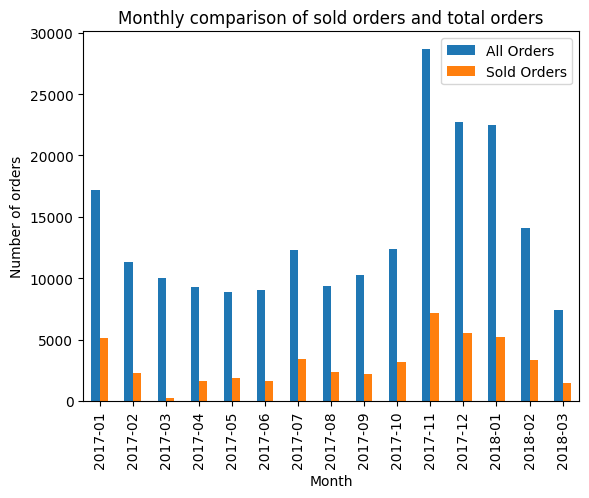

In [ ]:
#showing sold orders inside total orders per month
#making a column for month
orderlines_qu['month'] = orderlines_qu['date'].dt.to_period('M')
orderlines_completetd['month'] = orderlines_completetd['date'].dt.to_period('M').copy()

# customizing per month
all_orders_per_month = (
    orderlines_qu
    .groupby('month')['id_order']
    .nunique()
)

sold_orders_per_month = (
    orderlines_completetd
    .groupby('month')['id_order']
    .nunique()
)

# combine total orders and sold orders
monthly_comparison = pd.DataFrame({
    'All Orders': all_orders_per_month,
    'Sold Orders': sold_orders_per_month
})

# plotting
monthly_comparison.plot(
    kind='bar',
    title='Monthly comparison of sold orders and total orders',
    xlabel='Month',
    ylabel='Number of orders'
)

What is the overall revenue for that time?

In [ ]:
#1.Calculate the total amount paid across all orders.
#2.Calculate `unit_price × product_quantity` for each row, then sum all the values.(new column : revenue, we calculated this column before)
total_revenue= orderlines_qu['revenue'].sum()
print(f"Total revenue: {total_revenue:,.2f} EUR")

Total revenue: 14,620,744.47 EUR


<Axes: title={'center': 'Monthly revenue'}, xlabel='Month', ylabel='Revenue(EUR)'>

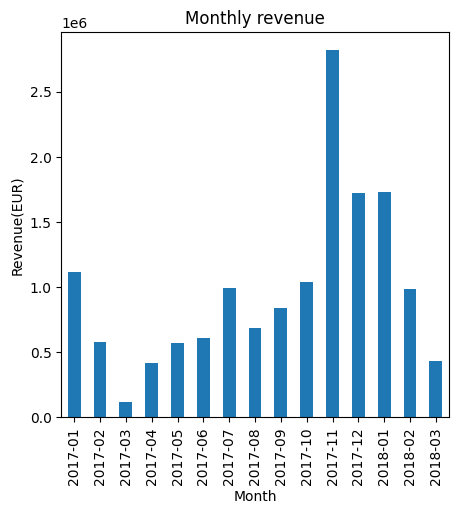

In [ ]:
#Monthly sales
#we added this column orderlines_qu['year'] before
#we added this column orderlines_qu['month'] before

monthly_revenue = orderlines_qu.groupby(['month'])['revenue'].sum()
monthly_revenue.plot(kind='bar', title='Monthly revenue',xlabel='Month',ylabel='Revenue(EUR)',figsize=(5,5),rot=90)

Are there seasonal patterns in the evolution of sales?

<Axes: title={'center': 'Quarter average revenue'}, xlabel='Quarter', ylabel='Revenue(EUR)'>

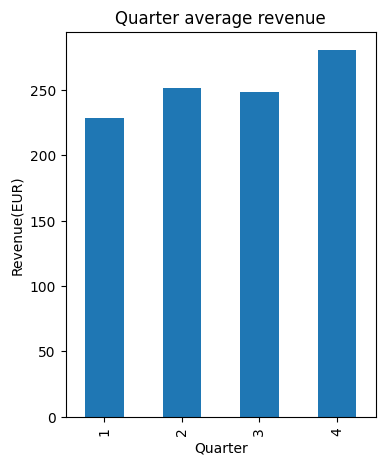

In [ ]:
quarter_avg = orderlines_qu.groupby('quarter')['revenue'].mean()
quarter_avg.plot(kind='bar', title='Quarter average revenue',xlabel='Quarter',ylabel='Revenue(EUR)',figsize=(4,5),rot=90)

In [ ]:
best_quarter= quarter_avg.idxmax()
worst_quarter= quarter_avg.idxmin()
print(f"\nBest quarter: Q{best_quarter} with {quarter_avg[best_quarter]:,.2f} EUR")
print(f"Worst quarter: Q{worst_quarter} with {quarter_avg[worst_quarter]:,.2f} EUR")


Best quarter: Q4 with 280.24 EUR
Worst quarter: Q1 with 228.43 EUR


What are the most sold products?

In [ ]:
#1. Calculate the number of units sold for each product.
#2. Sort the products from best-selling to least-selling.
product_sales = orderlines_completetd.groupby('sku')['product_quantity'].sum()
top_product = product_sales.sort_values(ascending=False).head(10)
product_qu.loc[product_qu['sku'].isin(top_product.index),:]


,sku,name,desc,price,in_stock,type
139,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4T...,169.00,1,12655397
151,NTE0013,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",Adapter HDD / SSD 2.5 SATA 3.5 compatible with...,26.99,1,12755395
625,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
1215,SAM0074,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA I...,179.99,1,12215397
1439,APP0927,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1,5384
2613,APP1190,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.,70.00,1,1231
2863,APP1214,Apple Magic Mouse 2,Bluetooth Apple Wireless Mouse,89.00,1,1387
4883,CRU0051,Crucial MX300 525GB SSD Disk,SSD 525GB SATA Hard Disk 3.0 (6Gb / s) for Mac...,158.66,0,12215397
5484,APP1922,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...,179.00,1,5384
7991,APP2446,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray,449.33,0,21561716


What are the products that generate the most revenue?

In [ ]:
orderlines_completetd['revenue'] = orderlines_completetd['unit_price']*orderlines_completetd['product_quantity']

In [ ]:
#1. Calculate the revenue for each product (`unit_price × product_quantity`).
#2. Sort the products by revenue.
product_revenue = orderlines_completetd.groupby('sku')['revenue'].sum()
top_revenue_product = product_revenue.sort_values(ascending=False).head(10)
product_qu.loc[product_qu['sku'].isin(top_revenue_product.index),:]
#top_revenue_product

,sku,name,desc,price,in_stock,type
5194,LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",99% Professional Monitor sRGB color calibrator...,599.00,1,1296
5793,APP1956,"Apple MacBook Pro Retina 13 ""Core i7 3GHz | 8G...",MacBook Pro early 2015 with Retina display 13-...,2769.00,0,1282
7286,APP2089,"Apple iMac 27 ""Core i5 3.4Ghz 5K Retina | 8GB ...",IMac desktop computer 27 inch 5K Retina 8GB RA...,2105.59,1,"5,74E+15"
7288,PAC2136,"Apple iMac 27 ""Core i5 Retina 5K 34GHz | 16GB ...",IMac desktop computer 27 inch 5K Retina 16GB (...,2339.00,1,"5,74E+15"
7384,APP2074,"Apple MacBook Pro 15 ""Core i7 Touch Bar 28GHz ...",New MacBook Pro 15-inch Touch Bar to 28GHz Cor...,2805.59,1,"1,02E+12"
7412,APP2075,"Apple MacBook Pro 15 ""Core i7 Touch Bar 29Ghz ...",New MacBook Pro 15-inch Core i7 Touch Bar 29Gh...,3305.59,0,"1,02E+12"
7513,APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",laptop MacBook Air 13 inch i5 18GHz 8GB RAM an...,1105.59,1,"2,17E+11"
7586,APP2073,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",laptop MacBook Air 13 inch i5 18GHz 8GB RAM an...,1355.59,1,"2,17E+11"
7991,APP2446,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray,449.33,0,21561716
8220,APP2489,Apple iPhone 64GB Space Gray X,New Free iPhone 64GB X,1159.00,1,113271716


##1.4 Saving Files

In [ ]:
from google.colab import files

orders_qu.to_csv("orders_qa.csv", index=False)
files.download("orders_qa.csv")

orderlines_qu.to_csv("orderlines_qa.csv", index=False)
files.download("orderlines_qa.csv")

product_qu.to_csv("products_qa.csv", index=False)
files.download("products_qa.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>